In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, GRU
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/kkkushagra/tweets/Tweets.csv")
print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [23]:
df = df[['text','sentiment']]
print(df.head())

                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative


In [24]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [25]:
print(df['sentiment'])

0        1
1        0
2        0
3        0
4        0
        ..
27476    0
27477    0
27478    2
27479    2
27480    1
Name: sentiment, Length: 27481, dtype: int64


In [26]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)   # remove links
    text = re.sub(r'@\w+', '', text)      # remove mentions
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove special chars
    return text

df['text'] = df['text'].fillna('').astype(str)
df['text'] = df['text'].apply(clean_text)

In [27]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=100)

y = df['sentiment']

In [28]:
print(df['text'].isnull().sum())

0


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',     # watch validation performance
    patience=2,            # stop after 2 bad epochs
    restore_best_weights=True
)

In [31]:
rnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')   # 3 sentiments
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.4474 - loss: 1.0497 - val_accuracy: 0.6514 - val_loss: 0.7770
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7206 - loss: 0.6713 - val_accuracy: 0.6662 - val_loss: 0.7608
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8381 - loss: 0.4394 - val_accuracy: 0.6695 - val_loss: 0.8340
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9134 - loss: 0.2619 - val_accuracy: 0.6282 - val_loss: 1.0554


In [33]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.5012 - loss: 0.9662 - val_accuracy: 0.6951 - val_loss: 0.7076
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.7425 - loss: 0.6327 - val_accuracy: 0.7137 - val_loss: 0.6925
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.7888 - loss: 0.5406 - val_accuracy: 0.7142 - val_loss: 0.6982
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.8119 - loss: 0.4926 - val_accuracy: 0.7106 - val_loss: 0.7285


In [35]:
gru_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.5049 - loss: 0.9620 - val_accuracy: 0.6998 - val_loss: 0.7090
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.7464 - loss: 0.6275 - val_accuracy: 0.7124 - val_loss: 0.6789
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.7813 - loss: 0.5437 - val_accuracy: 0.7180 - val_loss: 0.6904
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.8112 - loss: 0.4808 - val_accuracy: 0.7128 - val_loss: 0.7181


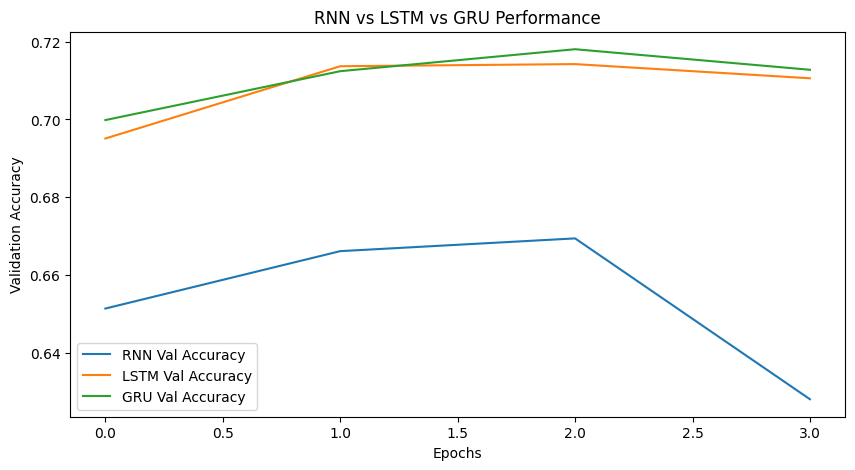

In [37]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('RNN vs LSTM vs GRU Performance')
plt.legend()

plt.show()